#### 1. DOWNLOADING DATA

In [1]:
# importing necessary library
import torch 
from torch import nn

print(f"Version of torch: {torch.__version__}")

Version of torch: 2.10.0+cu128


In [2]:
!nvidia-smi

Sat Mar 28 12:08:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Setting device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# Downloading data 
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


#### 2. VISUALIZE IMAGE

In [5]:
import os
def walk_through_dir(dir_path):
    for dirpath, dirname, filenames in os.walk(dir_path):
        print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'")

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'


In [7]:
train_dir = image_path/ "train"
test_dir = image_path/ "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [8]:
image_path

PosixPath('data/pizza_steak_sushi')

In [9]:
image_path_list = list(image_path.glob('*/*/*.jpg'))
image_path_list

[PosixPath('data/pizza_steak_sushi/train/pizza/765799.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1572608.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/29417.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1633289.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1649276.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3699992.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1660415.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1524655.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3269634.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2569760.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/220190.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2382016.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/667309.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/393658.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1412034.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3018077.jpg'),
 PosixPath('da

Image path: data/pizza_steak_sushi/train/pizza/2687575.jpg
Class name: pizza
Height: 384
Width: 512


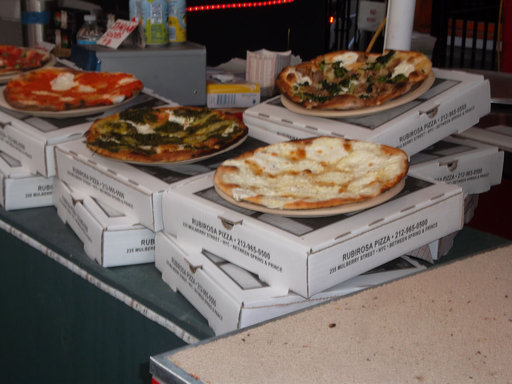

In [10]:
import random 
from PIL import Image 

random.seed(42)

image_path_list = list(image_path.glob('*/*/*.jpg'))

random_image_path = random.choice(image_path_list)
# print(random_image_path)

image_class = random_image_path.parent.stem
# print(image_class)

img = Image.open(random_image_path)
print(f"Image path: {random_image_path}")
print(f"Class name: {image_class}")
print(f"Height: {img.height}")
print(f"Width: {img.width}")
img

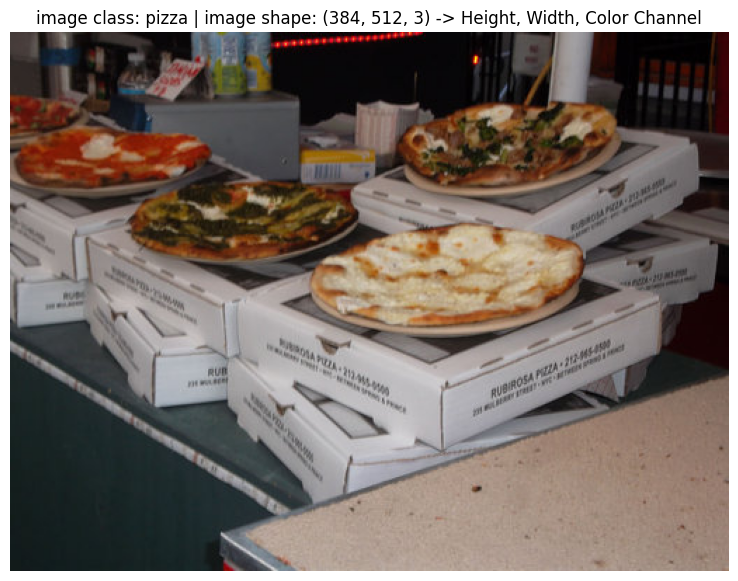

In [11]:
import numpy as np 
import matplotlib.pyplot as plt 

image_array = np.asarray(img)
plt.figure(figsize=(10,7))
plt.imshow(image_array)
plt.title(f"image class: {image_class} | image shape: {image_array.shape} -> Height, Width, Color Channel")
plt.axis("off")
plt.show()

#### 3. Transform Data

In [12]:
import torchvision

In [13]:
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [14]:
transforms_data = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ToTensor() ])

In [15]:
transforms_data(img)

tensor([[[0.2706, 0.2745, 0.2824,  ..., 0.1765, 0.1922, 0.2118],
         [0.2745, 0.2784, 0.2863,  ..., 0.1725, 0.1961, 0.2196],
         [0.2745, 0.2824, 0.2863,  ..., 0.1608, 0.1882, 0.2196],
         ...,
         [0.0706, 0.0706, 0.0667,  ..., 0.6157, 0.6118, 0.6157],
         [0.0706, 0.0706, 0.0667,  ..., 0.6235, 0.6157, 0.6118],
         [0.0706, 0.0706, 0.0745,  ..., 0.6275, 0.6118, 0.6235]],

        [[0.2353, 0.2353, 0.2392,  ..., 0.0667, 0.0196, 0.0118],
         [0.2392, 0.2392, 0.2471,  ..., 0.0627, 0.0157, 0.0118],
         [0.2392, 0.2392, 0.2471,  ..., 0.0588, 0.0118, 0.0078],
         ...,
         [0.1059, 0.1059, 0.1020,  ..., 0.5255, 0.5255, 0.5255],
         [0.1059, 0.1059, 0.1059,  ..., 0.5373, 0.5294, 0.5333],
         [0.1059, 0.1059, 0.1020,  ..., 0.5412, 0.5216, 0.5176]],

        [[0.2235, 0.2275, 0.2314,  ..., 0.0353, 0.0235, 0.0275],
         [0.2275, 0.2314, 0.2392,  ..., 0.0353, 0.0275, 0.0314],
         [0.2275, 0.2314, 0.2392,  ..., 0.0314, 0.0235, 0.

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

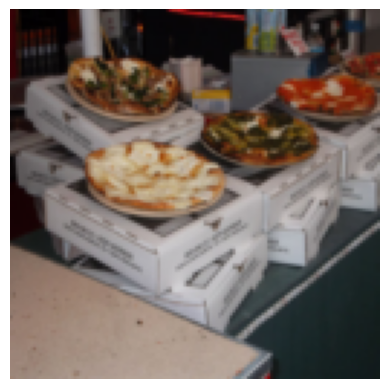

In [16]:
plt.imshow(transforms_data(img).permute(1,2,0))
plt.axis("off")

In [17]:
def plot_transformed_image(image_path_list, transforms, n=3, seed=42):
    random.seed(seed)
    random_image_path = random.sample(image_path_list, k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as f: 
            fig, ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\n size:{f.size}")
            ax[0].axis("off")
            
            transformed_image = transforms(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\n size:{transformed_image.shape}")
            ax[1].axis("off")
            
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


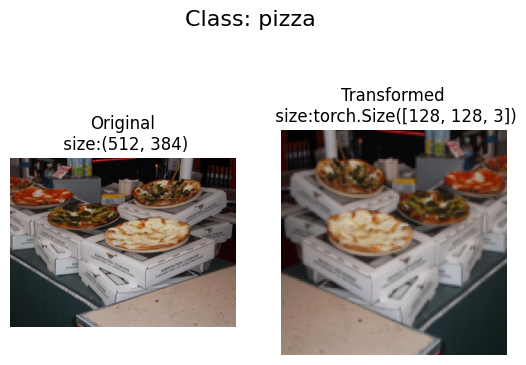

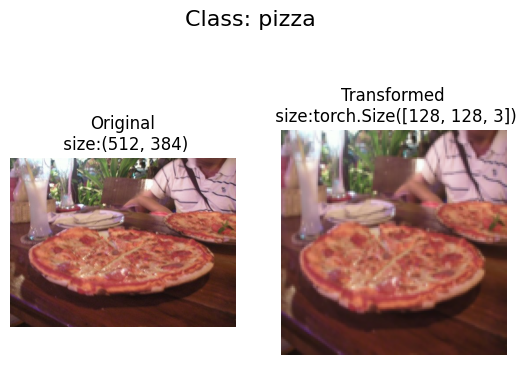

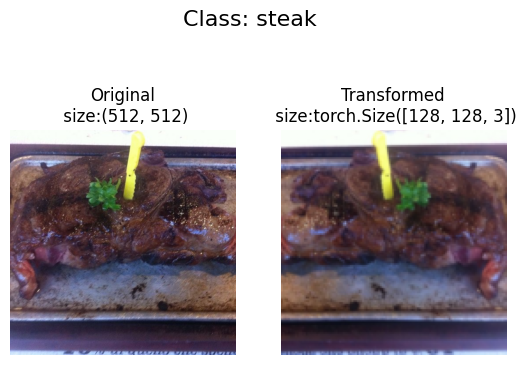

In [18]:
plot_transformed_image(image_path_list=image_path_list, 
                       transforms=transforms_data, )

#### 4. LOADING IMAGE

In [21]:
train_dir

PosixPath('data/pizza_steak_sushi/train')

In [23]:
# option 1: using ImageFolder
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir, 
                                  transform= transforms_data, 
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir, 
                                  transform= transforms_data, 
                                  target_transform=None)

In [24]:
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [25]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [27]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [28]:
len(train_data), len(test_data)

(225, 75)

In [36]:
train_data[0]

(tensor([[[0.1137, 0.1137, 0.1059,  ..., 0.1098, 0.1098, 0.1137],
          [0.1137, 0.1098, 0.1059,  ..., 0.1216, 0.1216, 0.1255],
          [0.1098, 0.1059, 0.1020,  ..., 0.1294, 0.1294, 0.1333],
          ...,
          [0.0824, 0.0863, 0.0902,  ..., 0.1647, 0.1686, 0.1765],
          [0.0902, 0.0863, 0.0824,  ..., 0.1647, 0.1686, 0.1765],
          [0.0863, 0.0824, 0.0824,  ..., 0.1569, 0.1569, 0.1608]],
 
         [[0.0706, 0.0745, 0.0706,  ..., 0.0549, 0.0549, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0745, 0.0745, 0.0745,  ..., 0.0627, 0.0627, 0.0667],
          ...,
          [0.1059, 0.1098, 0.1098,  ..., 0.2275, 0.2275, 0.2314],
          [0.1059, 0.1020, 0.1020,  ..., 0.2275, 0.2314, 0.2314],
          [0.1020, 0.0980, 0.0980,  ..., 0.2353, 0.2275, 0.2275]],
 
         [[0.0941, 0.0980, 0.0902,  ..., 0.0196, 0.0196, 0.0196],
          [0.0941, 0.0941, 0.0902,  ..., 0.0235, 0.0235, 0.0235],
          [0.0941, 0.0941, 0.0902,  ...,

In [38]:
image, label = train_data[0][0], train_data[0][1]

In [44]:
print(f"Image tensor:\n{image}")
print(f"Image shape: {image.shape}")
print(f"Image datatype: {image.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1137, 0.1137, 0.1059,  ..., 0.1098, 0.1098, 0.1137],
         [0.1137, 0.1098, 0.1059,  ..., 0.1216, 0.1216, 0.1255],
         [0.1098, 0.1059, 0.1020,  ..., 0.1294, 0.1294, 0.1333],
         ...,
         [0.0824, 0.0863, 0.0902,  ..., 0.1647, 0.1686, 0.1765],
         [0.0902, 0.0863, 0.0824,  ..., 0.1647, 0.1686, 0.1765],
         [0.0863, 0.0824, 0.0824,  ..., 0.1569, 0.1569, 0.1608]],

        [[0.0706, 0.0745, 0.0706,  ..., 0.0549, 0.0549, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0745, 0.0745, 0.0745,  ..., 0.0627, 0.0627, 0.0667],
         ...,
         [0.1059, 0.1098, 0.1098,  ..., 0.2275, 0.2275, 0.2314],
         [0.1059, 0.1020, 0.1020,  ..., 0.2275, 0.2314, 0.2314],
         [0.1020, 0.0980, 0.0980,  ..., 0.2353, 0.2275, 0.2275]],

        [[0.0941, 0.0980, 0.0902,  ..., 0.0196, 0.0196, 0.0196],
         [0.0941, 0.0941, 0.0902,  ..., 0.0235, 0.0235, 0.0235],
         [0.0941, 0.0941, 0.0902,  ..., 0.01

Original shape: torch.Size([3, 128, 128]) -> [color_channels, height, width]
Image permute shape: torch.Size([128, 128, 3]) -> [height, width, color_channels]


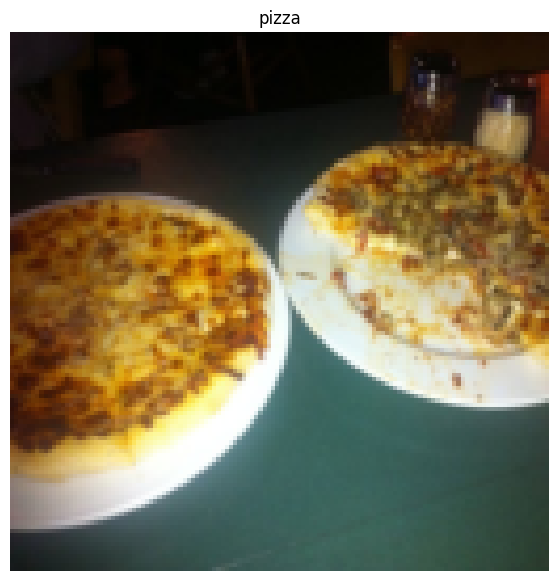

In [43]:
image_permuted = image.permute(1,2,0)

# Print out different shapes (before and after permute)
print(f"Original shape: {image.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {image_permuted.shape} -> [height, width, color_channels]")


plt.figure(figsize=(10,7))
plt.imshow(image_permuted)
plt.title(label=class_names[label])
plt.axis("off")
plt.show()

In [45]:
import os 
os.cpu_count()

2

In [72]:
# Loading Image tensor using DataLoader 
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=16, 
                              shuffle=True, 
                              num_workers=2)

test_dataloader = DataLoader(dataset=test_data, 
                             batch_size=16, 
                             shuffle=False, 
                             num_workers=2)


In [73]:
img, label = next(iter(train_dataloader))

In [76]:
print(f"Shape of image: {img.shape} -> [batch_size, Color_Channel, Height, Width]")
print(f"Label: {label}")

Shape of image: torch.Size([16, 3, 128, 128]) -> [batch_size, Color_Channel, Height, Width]
Label: tensor([1, 0, 2, 1, 1, 2, 2, 0, 1, 1, 1, 2, 1, 1, 0, 2])


Text(0.5, 1.0, 'steak')

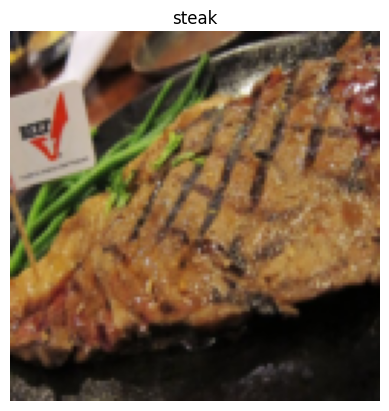

In [90]:
image = img[0]
plt.imshow(image.permute(1,2,0))
plt.axis("off")
plt.title(class_names[label[0]])